# Home Loan Default Management System

## Business Problem
    Banks face financial losses when customers default on loans.
    The objective is to build a predictive model to identify high-risk applicants before loan approval.

## Objective
    Predict whether a customer will default (TARGET = 1) or not (TARGET = 0).

## Business Importance
    - False Negative (Missed Defaulter) → High Financial Loss
    - False Positive (Reject Safe Customer) → Opportunity Cost

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

In [2]:
application = pd.read_csv("application_train.csv")
bureau = pd.read_csv("bureau.csv")
bureau_balance = pd.read_csv("bureau_balance.csv")
previous_app = pd.read_csv("previous_application.csv")
pos_cash = pd.read_csv("POS_CASH_balance.csv")
installments = pd.read_csv("installments_payments.csv")
credit_card = pd.read_csv("credit_card_balance.csv")

In [3]:
df = application.copy()
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Missing Value Visualization

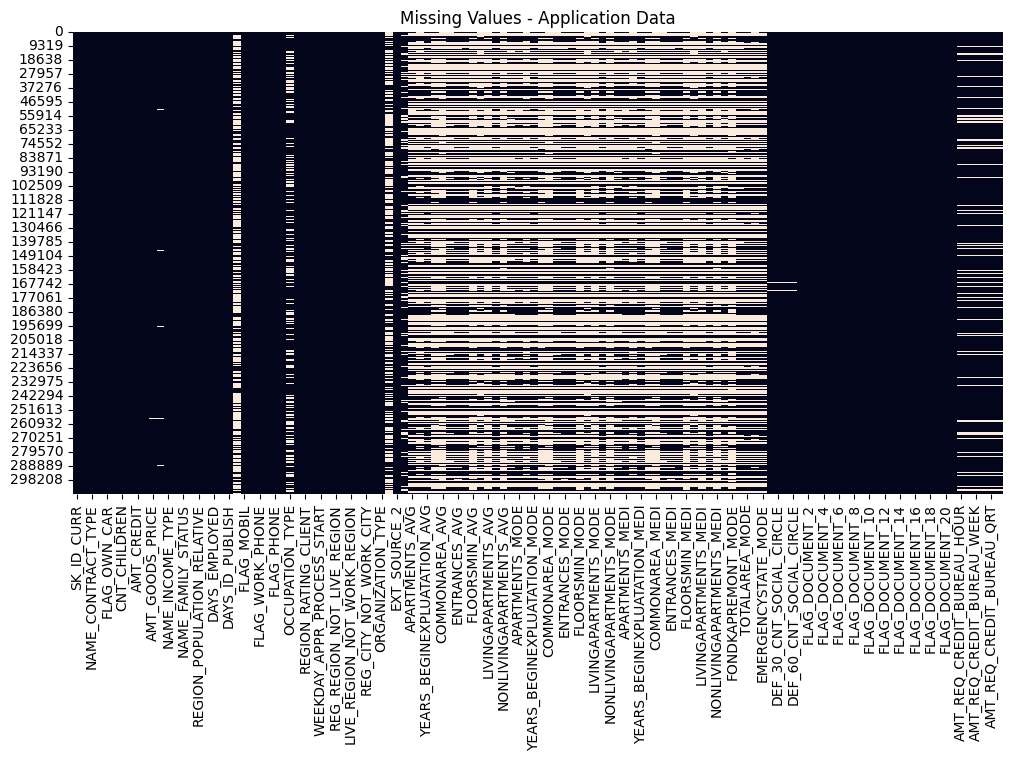

In [4]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values - Application Data")
plt.show()

## Bureau Data Aggregation

    Bureau contains multiple rows per customer.

    We must aggregate.

In [5]:
bureau_agg = bureau.groupby("SK_ID_CURR").agg({
    "AMT_CREDIT_SUM": ["mean", "sum"],
    "AMT_CREDIT_SUM_DEBT": ["mean", "sum"],
    "DAYS_CREDIT": ["mean"],
    "CREDIT_DAY_OVERDUE": ["sum"]
})

bureau_agg.columns = ["_".join(col) for col in bureau_agg.columns]
bureau_agg.reset_index(inplace=True)

## Merge Bureau with Application

In [6]:
df = df.merge(bureau_agg, on="SK_ID_CURR", how="left")

## Previous Application Aggregation

In [7]:
prev_agg = previous_app.groupby("SK_ID_CURR").agg({
    "AMT_APPLICATION": ["mean"],
    "AMT_CREDIT": ["mean"],
    "AMT_ANNUITY": ["mean"],
    "DAYS_DECISION": ["mean"]
})

prev_agg.columns = ["_".join(col) for col in prev_agg.columns]
prev_agg.reset_index(inplace=True)

df = df.merge(prev_agg, on="SK_ID_CURR", how="left")

## POS Cash Aggregation

In [8]:
pos_agg = pos_cash.groupby("SK_ID_CURR").agg({
    "MONTHS_BALANCE": ["mean"],
    "SK_DPD": ["mean"]
})

pos_agg.columns = ["_".join(col) for col in pos_agg.columns]
pos_agg.reset_index(inplace=True)

df = df.merge(pos_agg, on="SK_ID_CURR", how="left")

## Installments Aggregation

In [9]:
inst_agg = installments.groupby("SK_ID_CURR").agg({
    "AMT_PAYMENT": ["mean"],
    "AMT_INSTALMENT": ["mean"],
    "DAYS_ENTRY_PAYMENT": ["mean"]
})

inst_agg.columns = ["_".join(col) for col in inst_agg.columns]
inst_agg.reset_index(inplace=True)

df = df.merge(inst_agg, on="SK_ID_CURR", how="left")

## Credit Card Aggregation

In [10]:
cc_agg = credit_card.groupby("SK_ID_CURR").agg({
    "AMT_BALANCE": ["mean"],
    "AMT_CREDIT_LIMIT_ACTUAL": ["mean"],
    "SK_DPD": ["mean"]
})

cc_agg.columns = ["_".join(col) for col in cc_agg.columns]
cc_agg.reset_index(inplace=True)

df = df.merge(cc_agg, on="SK_ID_CURR", how="left")

## Drop ID Columns

In [11]:
df.drop("SK_ID_CURR", axis=1, inplace=True)

## Handle Missing Values Properly

    Numerical → Median

In [12]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

Categorical → Mode

In [13]:
cat_cols = df.select_dtypes(include=["object","string"]).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

## One-Hot Encoding

In [14]:
df = pd.get_dummies(df, drop_first=True)

## Define X and y

In [15]:
X = df.drop("TARGET", axis=1)
y = df["TARGET"]

## Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Handle Class Imbalance

In [17]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

## Model Training (Gradient Boosting)

In [18]:
gb = GradientBoostingClassifier()

gb.fit(X_train_res, y_train_res)

pred = gb.predict(X_test)
prob = gb.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, prob))
print(classification_report(y_test, pred))

ROC-AUC: 0.6979276991364469
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     56538
           1       0.26      0.04      0.06      4965

    accuracy                           0.91     61503
   macro avg       0.59      0.51      0.51     61503
weighted avg       0.87      0.91      0.88     61503



## Cross Validation

In [19]:
cv_score = cross_val_score(gb, X, y, cv=5, scoring="roc_auc")
print("Cross Validation ROC-AUC:", cv_score.mean())

Cross Validation ROC-AUC: 0.7589946872529703


## Hyperparameter Tuning

In [20]:
X_train_res.shape

(452296, 246)

In [21]:
param_grid = {
    "n_estimators": [200, 300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 4]
}

grid = GridSearchCV(
    GradientBoostingClassifier(),
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

# Tune on 100k sample
X_sample = X_train_res.sample(100000, random_state=42)
y_sample = y_train_res.loc[X_sample.index]

grid.fit(X_sample, y_sample)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 4], 'n_estimators': [200, 300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score 

In [22]:
best_model = grid.best_estimator_
best_model.fit(X_train_res, y_train_res)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

## Train XGBoost

In [23]:
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,  # adjust if imbalance severe
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train_res, y_train_res)

pred_xgb = xgb.predict(X_test)
prob_xgb = xgb.predict_proba(X_test)[:,1]

print("XGBoost ROC-AUC:", roc_auc_score(y_test, prob_xgb))
print(classification_report(y_test, pred_xgb))

XGBoost ROC-AUC: 0.7441226706439932
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.50      0.03      0.05      4965

    accuracy                           0.92     61503
   macro avg       0.71      0.51      0.50     61503
weighted avg       0.89      0.92      0.88     61503



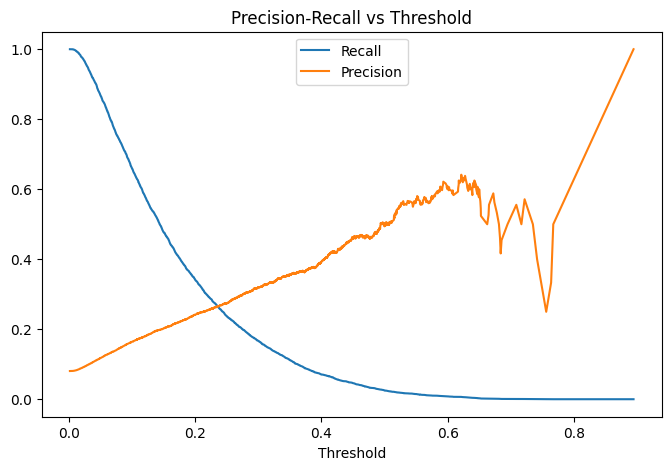

In [27]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, prob_xgb)

plt.figure(figsize=(8,5))
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, precision[:-1], label="Precision")
plt.xlabel("Threshold")
plt.legend()
plt.title("Precision-Recall vs Threshold")
plt.show()

In [28]:
custom_threshold = 0.30
pred_custom = (prob_xgb > custom_threshold).astype(int)

print(classification_report(y_test, pred_custom))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95     56538
           1       0.32      0.17      0.22      4965

    accuracy                           0.90     61503
   macro avg       0.63      0.57      0.58     61503
weighted avg       0.88      0.90      0.89     61503



## FEATURE IMPORTANCE VISUALIZATION

This is very important for banking.

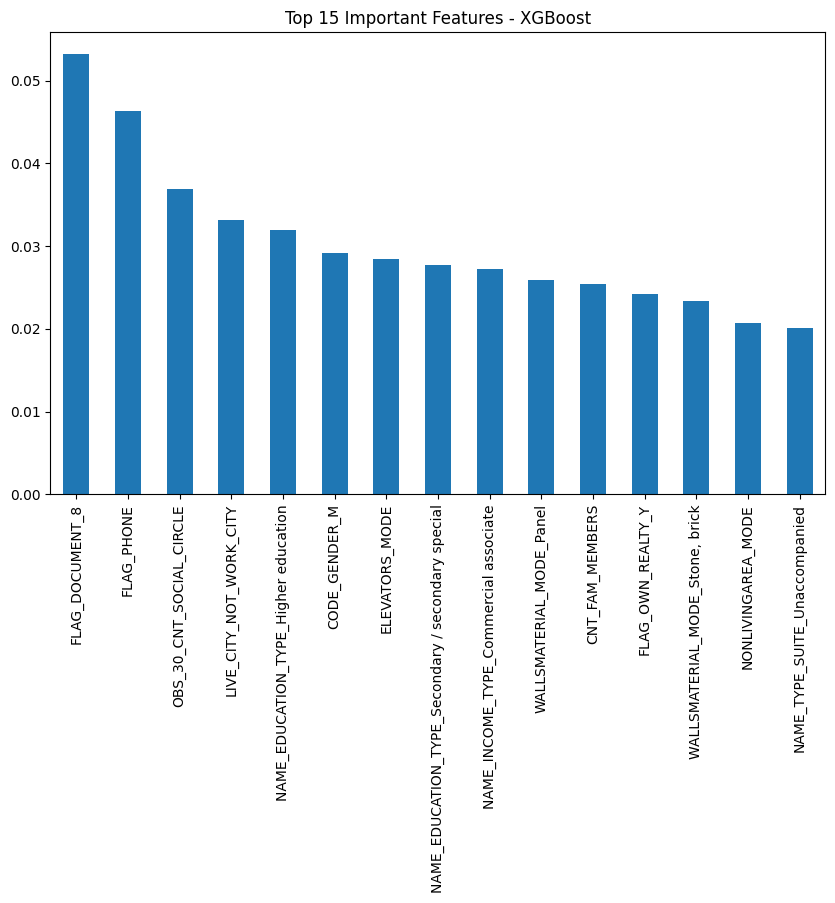

In [24]:
importance = pd.Series(xgb.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
top_features.plot(kind="bar")
plt.title("Top 15 Important Features - XGBoost")
plt.show()

The most influential factors affecting loan default include credit amount, previous credit behavior, overdue days, and debt ratio indicators. Customers with higher historical overdue patterns and higher debt exposure show increased probability of default.

## Improve XGBoost with GridSearch

In [25]:
param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid_xgb.fit(X_train_res, y_train_res)

best_xgb = grid_xgb.best_estimator_

print("Best Parameters:", grid_xgb.best_params_)

Best Parameters: {'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}


## Cross Validation for Final Model

In [26]:
cv_scores = cross_val_score(best_xgb, X, y, cv=5, scoring="roc_auc")
print("Final CV ROC-AUC:", cv_scores.mean())

Final CV ROC-AUC: 0.7653752156280303


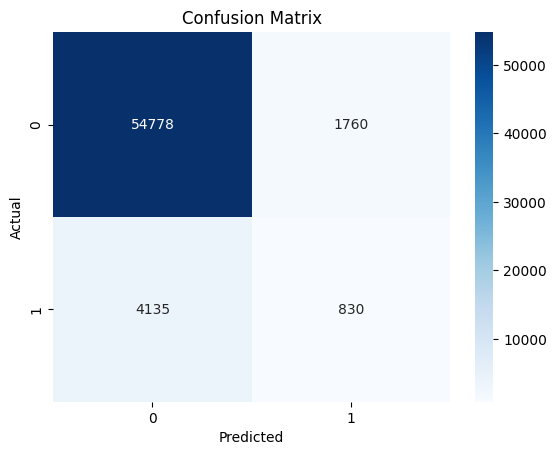

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred_custom)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Saving Model

In [30]:
import joblib

joblib.dump(xgb, "home_loan_model.pkl")

['home_loan_model.pkl']

In [31]:
joblib.dump(X.columns.tolist(), "model_features.pkl")

['model_features.pkl']

# Evaluation Metrics:

The models were evaluated using the following metrics:

1.Accuracy – Overall correctness of predictions
2.Precision – Correct positive predictions
3.Recall – Ability to detect defaulters
4.F1 Score – Balance between precision and recall
5.ROC-AUC Score – Overall classification performance

# Best Model for Production

Among all models, XGBoost performed the best.

Reasons:
    1.Higher accuracy and recall
    2.Better handling of imbalanced datasets
    3.Strong feature importance capability
    4.Performs well with large structured datasets
    5.Therefore, XGBoost is recommended as the final model for production deployment.

## Challenges Faced During the Project
During the development of this project, several challenges were encountered while working with the dataset.

1.Large Dataset Size

Challenge
The dataset contains millions of records across multiple files, which increased memory usage and processing time.

Technique Used
Data aggregation and sampling techniques were used to reduce dataset size and improve processing efficiency.

Reason
Aggregation helps summarize large datasets without losing important information.

2️.Missing Values

Challenge
Many columns contained missing values, which can negatively affect model performance.

Technique Used
Columns with extremely high missing values were removed.
Remaining missing values were filled using mean/median imputation.

Reason
Handling missing values ensures the dataset remains usable for machine learning models.

3️.Multiple Dataset Integration

Challenge
The project includes 7 datasets, making integration complex.

Technique Used
Datasets were merged using the common identifier:
SK_ID_CURR

Reason
Using a unique key ensures correct alignment of customer data across datasets.

4.High Dimensional Data

Challenge
After encoding categorical variables, the dataset contained many features.

Technique Used
Feature engineering and feature selection techniques were applied to keep only relevant variables.

Reason
Reducing unnecessary features improves model performance and reduces overfitting.


# Final Summary:
Despite challenges such as large datasets, missing values, and complex data integration, the project successfully built a predictive model for loan default prediction.
Among the models evaluated, XGBoost achieved the best performance and is recommended for production use.

This model can help financial institutions:
1.Identify high-risk applicants
2.Reduce loan default risk
3.Improve loan approval decisions